In [1]:
# import libraries
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

Target: loan_approved_amount_usd Goal: predict how much loan amount a bank approves for an applicant — a fresh angle from the other two, using applicant financial profile instead of operational/demographic data.



In [2]:
# import the dataset
df = pd.read_csv("C:/Users/USER/Desktop/finance_loan_DIRTY.csv")
df.head()

,region,employment_type,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,bank_data_version,loan_approved_amount_usd
0,Abuja,Self-employed,16825.0,484.0,9498.0,2.0,21282.0,7295.0,84.0,8086.500000,v2.1,67244
1,IBADAN,SELF-EMPLOYED,11488.0,323.0,135760.0,200.0,5882.0,6557.0,48.0,7688.333333,v2.1,37486
2,ABUJA,SELF-EMPLOYED,14432.0,591.0,6142.0,10.0,32986.0,6960.0,60.0,7471.833333,v2.1,73196
3,Lagos,Business Owner,23593.0,NaN,5211.0,23.0,53255.0,2438.0,60.0,2872.250000,v2.1,106918
4,Port Harcourt,Business Owner,"$24,972",479.0,11832.0,5.0,"$47,170",1614.0,12.0,2600.000000,v2.1,110359


In [3]:
df["region"].nunique

<bound method IndexOpsMixin.nunique of 0              Abuja 
1              IBADAN
2               ABUJA
3               Lagos
4      Port Harcourt 
            ...      
211     Port Harcourt
212              Kano
213              KANO
214            ibadan
215             ABUJA
Name: region, Length: 216, dtype: object>

In [4]:
{col: df[col].unique() for col in df.columns}

{'region': array(['Abuja ', 'IBADAN', 'ABUJA', 'Lagos', 'Port Harcourt ', 'abuja',
        'ibadan', 'Abuja', ' Kano', 'Kano', 'lagos', ' Lagos', 'LAGOS',
        ' Abuja', 'KANO', ' Port Harcourt', 'Kano ', 'kano', 'Lagos ',
        ' Ibadan', 'PORT HARCOURT', 'port harcourt', 'Port Harcourt',
        'Ibadan', 'Ibadan ', nan], dtype=object),
 'employment_type': array(['Self-employed ', 'SELF-EMPLOYED', 'Business Owner',
        'Business Owner ', 'self-employed', 'Self-Employed',
        ' Business Owner', ' Salaried', 'BUSINESS OWNER', 'SALARIED',
        ' Self-employed', 'salaried', 'business owner', 'Salaried ',
        'Salaried', nan], dtype=object),
 'applicant_monthly_income_usd': array(['16825.0', '11488.0', '14432.0', '23593.0', '$24,972', '17274.0',
        '23577.0', '2665.0', '22840.0', '16154.0', '23407.0', '23371.0',
        '1877.0', '1971.0', '24036.0', '$4,332', '18694.0', '19023.0',
        '10487.0', '10025.0', '7190.0', '13334.0', '12994.0', '23476.0',
        '$

### Observation 
'**Region**': has inconscitency in word ABUJA, abuja and Abuja, IBADAN, ibadan, PORT HARCOURT......

"**Employment_type**": 'SELF-EMPLOYED', 'self employed, 'BUSINESS OWNER',' Business Owner'......

'**Applicant_monthly_income** '# As I: inconsistent units and unwanted characters

'**employment year**': missing values, outlier 

As I go on, we will see and rectify various inconsistencies, null values, outliers, duplicates, incorrect data types, whitespaces, and more

### checking for the shape, information, null, duplicate 


In [5]:
#shape
df.shape

(216, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   region                         215 non-null    object 
 1   employment_type                215 non-null    object 
 2   applicant_monthly_income_usd   206 non-null    object 
 3   credit_score                   206 non-null    float64
 4   existing_debt_usd              205 non-null    float64
 5   employment_years               205 non-null    float64
 6   collateral_value_usd           206 non-null    object 
 7   monthly_expenses_usd           215 non-null    float64
 8   loan_tenure_months             215 non-null    float64
 9   total_monthly_obligations_usd  215 non-null    float64
 10  bank_data_version              211 non-null    object 
 11  loan_approved_amount_usd       203 non-null    object 
dtypes: float64(6), object(6)
memory usage: 20.4+ KB


There are 216 observations based on the non-null count; I realize that there are missing values. Should I go on to check for the missing values, correct the inconsistencies, or find out the duplicated values? Let's correct the inconsistencies in the values. 
Here we see that the data types for the following columns are not well placed: applicant_monthly_income_usd, applicant_monthly_income_usd,collateral_value_usd,   loan_approved_amount_usd. ADo not forget that region and employment type also have inconsistent data.


In [7]:
for col in ["region", "employment_type", "bank_data_version"]: 
    df[col]= (df[col].astype(str).str.strip().str.replace("-", "_").str.replace(".", "_").str.replace(" ", "_", regex = False).str.capitalize())

In [8]:
df

,region,employment_type,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,bank_data_version,loan_approved_amount_usd
0,Abuja,Self_employed,16825.0,484.0,9498.0,2.0,21282.0,7295.0,84.0,8086.500000,V2_1,67244
1,Ibadan,Self_employed,11488.0,323.0,135760.0,200.0,5882.0,6557.0,48.0,7688.333333,V2_1,37486
2,Abuja,Self_employed,14432.0,591.0,6142.0,10.0,32986.0,6960.0,60.0,7471.833333,V2_1,73196
3,Lagos,Business_owner,23593.0,NaN,5211.0,23.0,53255.0,2438.0,60.0,2872.250000,V2_1,106918
4,Port_harcourt,Business_owner,"$24,972",479.0,11832.0,5.0,"$47,170",1614.0,12.0,2600.000000,V2_1,110359
...,...,...,...,...,...,...,...,...,...,...,...,...
211,Port_harcourt,Business_owner,18440.0,595.0,12900.0,14.0,57213.0,7841.0,24.0,8916.000000,V2_1,93995
212,Kano,Business_owner,21512.0,474.0,1968.0,11.0,45662.0,5966.0,120.0,6130.000000,V2_1,103280
213,Kano,Salaried,10983.0,701.0,6347.0,17.0,58388.0,6145.0,60.0,6673.916667,V2_1,83707
214,Ibadan,Salaried,8726.0,324.0,2981.0,18.0,6848.0,5559.0,84.0,5807.416667,V2_1,37143


In [9]:
# let us move into the numeric datatype
for col in ["applicant_monthly_income_usd", "collateral_value_usd"]:
    df[col] = (df[col].astype(str).str.replace( r"[$,]", "", regex = True).astype(float))

In [11]:
df["loan_approved_amount_usd"] =df["loan_approved_amount_usd"].replace("pending review", "NAN").astype(float)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   region                         216 non-null    object 
 1   employment_type                216 non-null    object 
 2   applicant_monthly_income_usd   206 non-null    float64
 3   credit_score                   206 non-null    float64
 4   existing_debt_usd              205 non-null    float64
 5   employment_years               205 non-null    float64
 6   collateral_value_usd           206 non-null    float64
 7   monthly_expenses_usd           215 non-null    float64
 8   loan_tenure_months             215 non-null    float64
 9   total_monthly_obligations_usd  215 non-null    float64
 10  bank_data_version              216 non-null    object 
 11  loan_approved_amount_usd       202 non-null    float64
dtypes: float64(9), object(3)
memory usage: 20.4+ KB


In [13]:
# checking again for unique items, inconsistencies 
{col: df[col].unique() for col in df.columns}

{'region': array(['Abuja', 'Ibadan', 'Lagos', 'Port_harcourt', 'Kano', 'Nan'],
       dtype=object),
 'employment_type': array(['Self_employed', 'Business_owner', 'Salaried', 'Nan'], dtype=object),
 'applicant_monthly_income_usd': array([16825., 11488., 14432., 23593., 24972., 17274., 23577.,  2665.,
        22840., 16154., 23407., 23371.,  1877.,  1971., 24036.,  4332.,
        18694., 19023., 10487., 10025.,  7190., 13334., 12994., 23476.,
         3008.,  2670.,  2283., 20641., 10418., 20645., 21042.,    nan,
        18178., 14458.,  2010., 18440., 19080., 11867., 13628., 22541.,
        18949., 18170., 20493.,  9363.,  5261., 10782.,  1863.,  7401.,
        17779., 16433.,  6045., 20497.,  8478., 22452.,  7758.,  9556.,
        15509.,  6310., 22014.,  7317., 13865., 20654.,  9141., 19657.,
        18893., 10917., 18107.,  8920.,  5857.,  4615.,  8116.,  9151.,
         6216., 20456., 19916.,  9455.,  5290.,  2384., 21297., 12119.,
         6551., 14917.,  3292., 22438.,  9939.,  1

In [14]:
# duplicate values 
df.duplicated().sum()

np.int64(5)

In [15]:
df[df.duplicated()]

,region,employment_type,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,bank_data_version,loan_approved_amount_usd
47,Lagos,Business_owner,21042.0,511.0,4132.0,20.0,32318.0,7903.0,12.0,8247.333333,V2_1,89980.0
147,Abuja,Business_owner,24036.0,819.0,14564.0,14.0,23683.0,2058.0,120.0,3271.666667,V2_1,113922.0
156,Ibadan,Business_owner,20988.0,371.0,10821.0,19.0,7115.0,6786.0,84.0,7687.750000,V2_1,79477.0
189,Lagos,Business_owner,11651.0,673.0,10695.0,14.0,53170.0,853.0,24.0,1744.250000,V2_1,85809.0
211,Port_harcourt,Business_owner,18440.0,595.0,12900.0,14.0,57213.0,7841.0,24.0,8916.000000,V2_1,93995.0


In [16]:
# dropping the duplicates 
df.drop_duplicates(inplace = True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
#null values
df.isnull().sum()

region                            0
employment_type                   0
applicant_monthly_income_usd     10
credit_score                     10
existing_debt_usd                11
employment_years                 11
collateral_value_usd             10
monthly_expenses_usd              1
loan_tenure_months                1
total_monthly_obligations_usd     1
bank_data_version                 0
loan_approved_amount_usd         14
dtype: int64

In [19]:
df[df["applicant_monthly_income_usd"].isnull()]

,region,employment_type,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,bank_data_version,loan_approved_amount_usd
31,Ibadan,Salaried,NaN,377.0,102990.0,240.0,NaN,2388.0,120.0,3246.250000,V2_1,40956.0
36,Port_harcourt,Salaried,NaN,702.0,147070.0,30.0,NaN,2178.0,60.0,3403.583333,V2_1,65141.0
83,Lagos,Salaried,NaN,534.0,15790.0,90.0,NaN,6800.0,84.0,6931.583333,V2_1,105504.0
96,Kano,Salaried,NaN,310.0,5790.0,120.0,NaN,2836.0,60.0,2884.250000,V2_1,54405.0
99,Kano,Business_owner,NaN,504.0,45220.0,70.0,NaN,4367.0,120.0,4743.833333,V2_1,91187.0
119,Nan,Nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nan,NaN
142,Kano,Self_employed,NaN,352.0,113570.0,220.0,NaN,2031.0,24.0,2977.416667,V2_1,35652.0
146,Port_harcourt,Business_owner,NaN,818.0,45960.0,90.0,NaN,3258.0,120.0,3641.000000,V2_1,72697.0
167,Ibadan,Self_employed,NaN,595.0,141400.0,0.0,NaN,6201.0,48.0,7379.333333,V2_1,54172.0
193,Abuja,Self_employed,NaN,910.0,14820.0,0.0,NaN,7650.0,36.0,7773.500000,Nan,NaN


In [20]:
df["applicant_monthly_income_usd"].mean()

np.float64(13313.97512437811)

In [21]:
df["applicant_monthly_income_usd"] = df["applicant_monthly_income_usd"].fillna(df["applicant_monthly_income_usd"].mean())

In [23]:
df[df["credit_score"].isnull()]

,region,employment_type,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,bank_data_version,loan_approved_amount_usd
3,Lagos,Business_owner,23593.000000,NaN,5211.0,23.0,53255.0,2438.0,60.0,2872.250000,V2_1,106918.0
20,Kano,Self_employed,7190.000000,NaN,4719.0,12.0,31808.0,5811.0,84.0,6204.250000,V2_1,62891.0
26,Kano,Self_employed,2283.000000,NaN,10833.0,12.0,3339.0,871.0,48.0,1773.750000,V2_1,NaN
29,Lagos,Self_employed,20645.000000,NaN,7392.0,7.0,29798.0,5940.0,36.0,6556.000000,V2_1,75987.0
46,Kano,Business_owner,10782.000000,NaN,3022.0,20.0,15877.0,6853.0,120.0,7104.833333,V2_1,73824.0
119,Nan,Nan,13313.975124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nan,NaN
152,Kano,Self_employed,8545.000000,NaN,4572.0,5.0,37613.0,6050.0,12.0,6431.000000,V2_1,47085.0
187,Port_harcourt,Salaried,14152.000000,NaN,11027.0,22.0,13973.0,795.0,12.0,1713.916667,V2_1,62811.0
197,Ibadan,Salaried,21540.000000,NaN,5299.0,11.0,35539.0,3164.0,36.0,3605.583333,V2_1,89226.0
202,Ibadan,Business_owner,15059.000000,NaN,14217.0,6.0,28269.0,4340.0,120.0,5524.750000,Nan,51076.0


In [24]:
df["credit_score"].mean()

np.float64(508.96019900497515)

In [25]:
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].mean())

In [26]:
df[df["existing_debt_usd"].isnull()]

,region,employment_type,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,bank_data_version,loan_approved_amount_usd
22,Kano,Business_owner,12994.000000,681.000000,NaN,NaN,44954.0,5531.0,12.0,6571.416667,V2_0,73392.0
32,Port_harcourt,Self_employed,18178.000000,837.000000,NaN,NaN,14515.0,4320.0,12.0,5048.916667,V2_1,93630.0
50,Abuja,Salaried,17779.000000,479.000000,NaN,NaN,70128.0,4788.0,36.0,5916.250000,V2_0,92347.0
52,Abuja,Salaried,6045.000000,786.000000,NaN,NaN,37816.0,6998.0,36.0,7505.250000,V2_0,62410.0
60,Lagos,Salaried,22014.000000,746.000000,NaN,NaN,23400.0,539.0,84.0,1272.500000,V2_1,106764.0
86,Lagos,Business_owner,22438.000000,481.000000,NaN,NaN,5881.0,4816.0,12.0,5680.166667,V2_0,90795.0
90,Ibadan,Salaried,19192.000000,344.000000,NaN,NaN,27283.0,6531.0,36.0,7770.333333,V2_1,NaN
112,Port_harcourt,Salaried,13179.000000,454.000000,NaN,NaN,18693.0,1716.0,36.0,2333.583333,V2_0,64587.0
119,Nan,Nan,13313.975124,508.960199,NaN,NaN,NaN,NaN,NaN,NaN,Nan,NaN
132,Lagos,Self_employed,10927.000000,520.000000,NaN,NaN,23345.0,3067.0,84.0,3462.916667,V2_1,68951.0


In [33]:
df["existing_debt_usd"] = df["existing_debt_usd"].fillna(0)

In [34]:
df

,region,employment_type,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,bank_data_version,loan_approved_amount_usd
0,Abuja,Self_employed,16825.0,484.000000,9498.0,2.0,21282.0,7295.0,84.0,8086.500000,V2_1,67244.0
1,Ibadan,Self_employed,11488.0,323.000000,135760.0,200.0,5882.0,6557.0,48.0,7688.333333,V2_1,37486.0
2,Abuja,Self_employed,14432.0,591.000000,6142.0,10.0,32986.0,6960.0,60.0,7471.833333,V2_1,73196.0
3,Lagos,Business_owner,23593.0,508.960199,5211.0,23.0,53255.0,2438.0,60.0,2872.250000,V2_1,106918.0
4,Port_harcourt,Business_owner,24972.0,479.000000,11832.0,5.0,47170.0,1614.0,12.0,2600.000000,V2_1,110359.0
...,...,...,...,...,...,...,...,...,...,...,...,...
210,Kano,Business_owner,22761.0,741.000000,7099.0,14.0,69770.0,1808.0,48.0,2399.583333,V2_1,130986.0
212,Kano,Business_owner,21512.0,474.000000,1968.0,11.0,45662.0,5966.0,120.0,6130.000000,V2_1,103280.0
213,Kano,Salaried,10983.0,701.000000,6347.0,17.0,58388.0,6145.0,60.0,6673.916667,V2_1,83707.0
214,Ibadan,Salaried,8726.0,324.000000,2981.0,18.0,6848.0,5559.0,84.0,5807.416667,V2_1,37143.0


In [35]:
 df["employment_years"]= df["employment_years"].fillna(0)

In [36]:
df["collateral_value_usd"]= df["collateral_value_usd"].fillna(0)

In [37]:
df["monthly_expenses_usd"] = df["monthly_expenses_usd"].fillna(0)

In [38]:
df["loan_tenure_months"] = df["loan_tenure_months"].fillna(0)

In [39]:
df["total_monthly_obligations_usd"] = df["total_monthly_obligations_usd"].fillna(0)

In [40]:
df.isnull().sum()

region                            0
employment_type                   0
applicant_monthly_income_usd      0
credit_score                      0
existing_debt_usd                 0
employment_years                  0
collateral_value_usd              0
monthly_expenses_usd              0
loan_tenure_months                0
total_monthly_obligations_usd     0
bank_data_version                 0
loan_approved_amount_usd         14
dtype: int64

In [42]:
df["loan_approved_amount_usd"] = df["loan_approved_amount_usd"].fillna(df["loan_approved_amount_usd"].mean())

In [35]:
df.isnull().sum()

region                           0
employment_type                  0
applicant_monthly_income_usd     0
credit_score                     0
existing_debt_usd                0
employment_years                 0
collateral_value_usd             0
monthly_expenses_usd             0
loan_tenure_months               0
total_monthly_obligations_usd    0
bank_data_version                0
loan_approved_amount_usd         0
dtype: int64

In [43]:
df.shape

(211, 12)

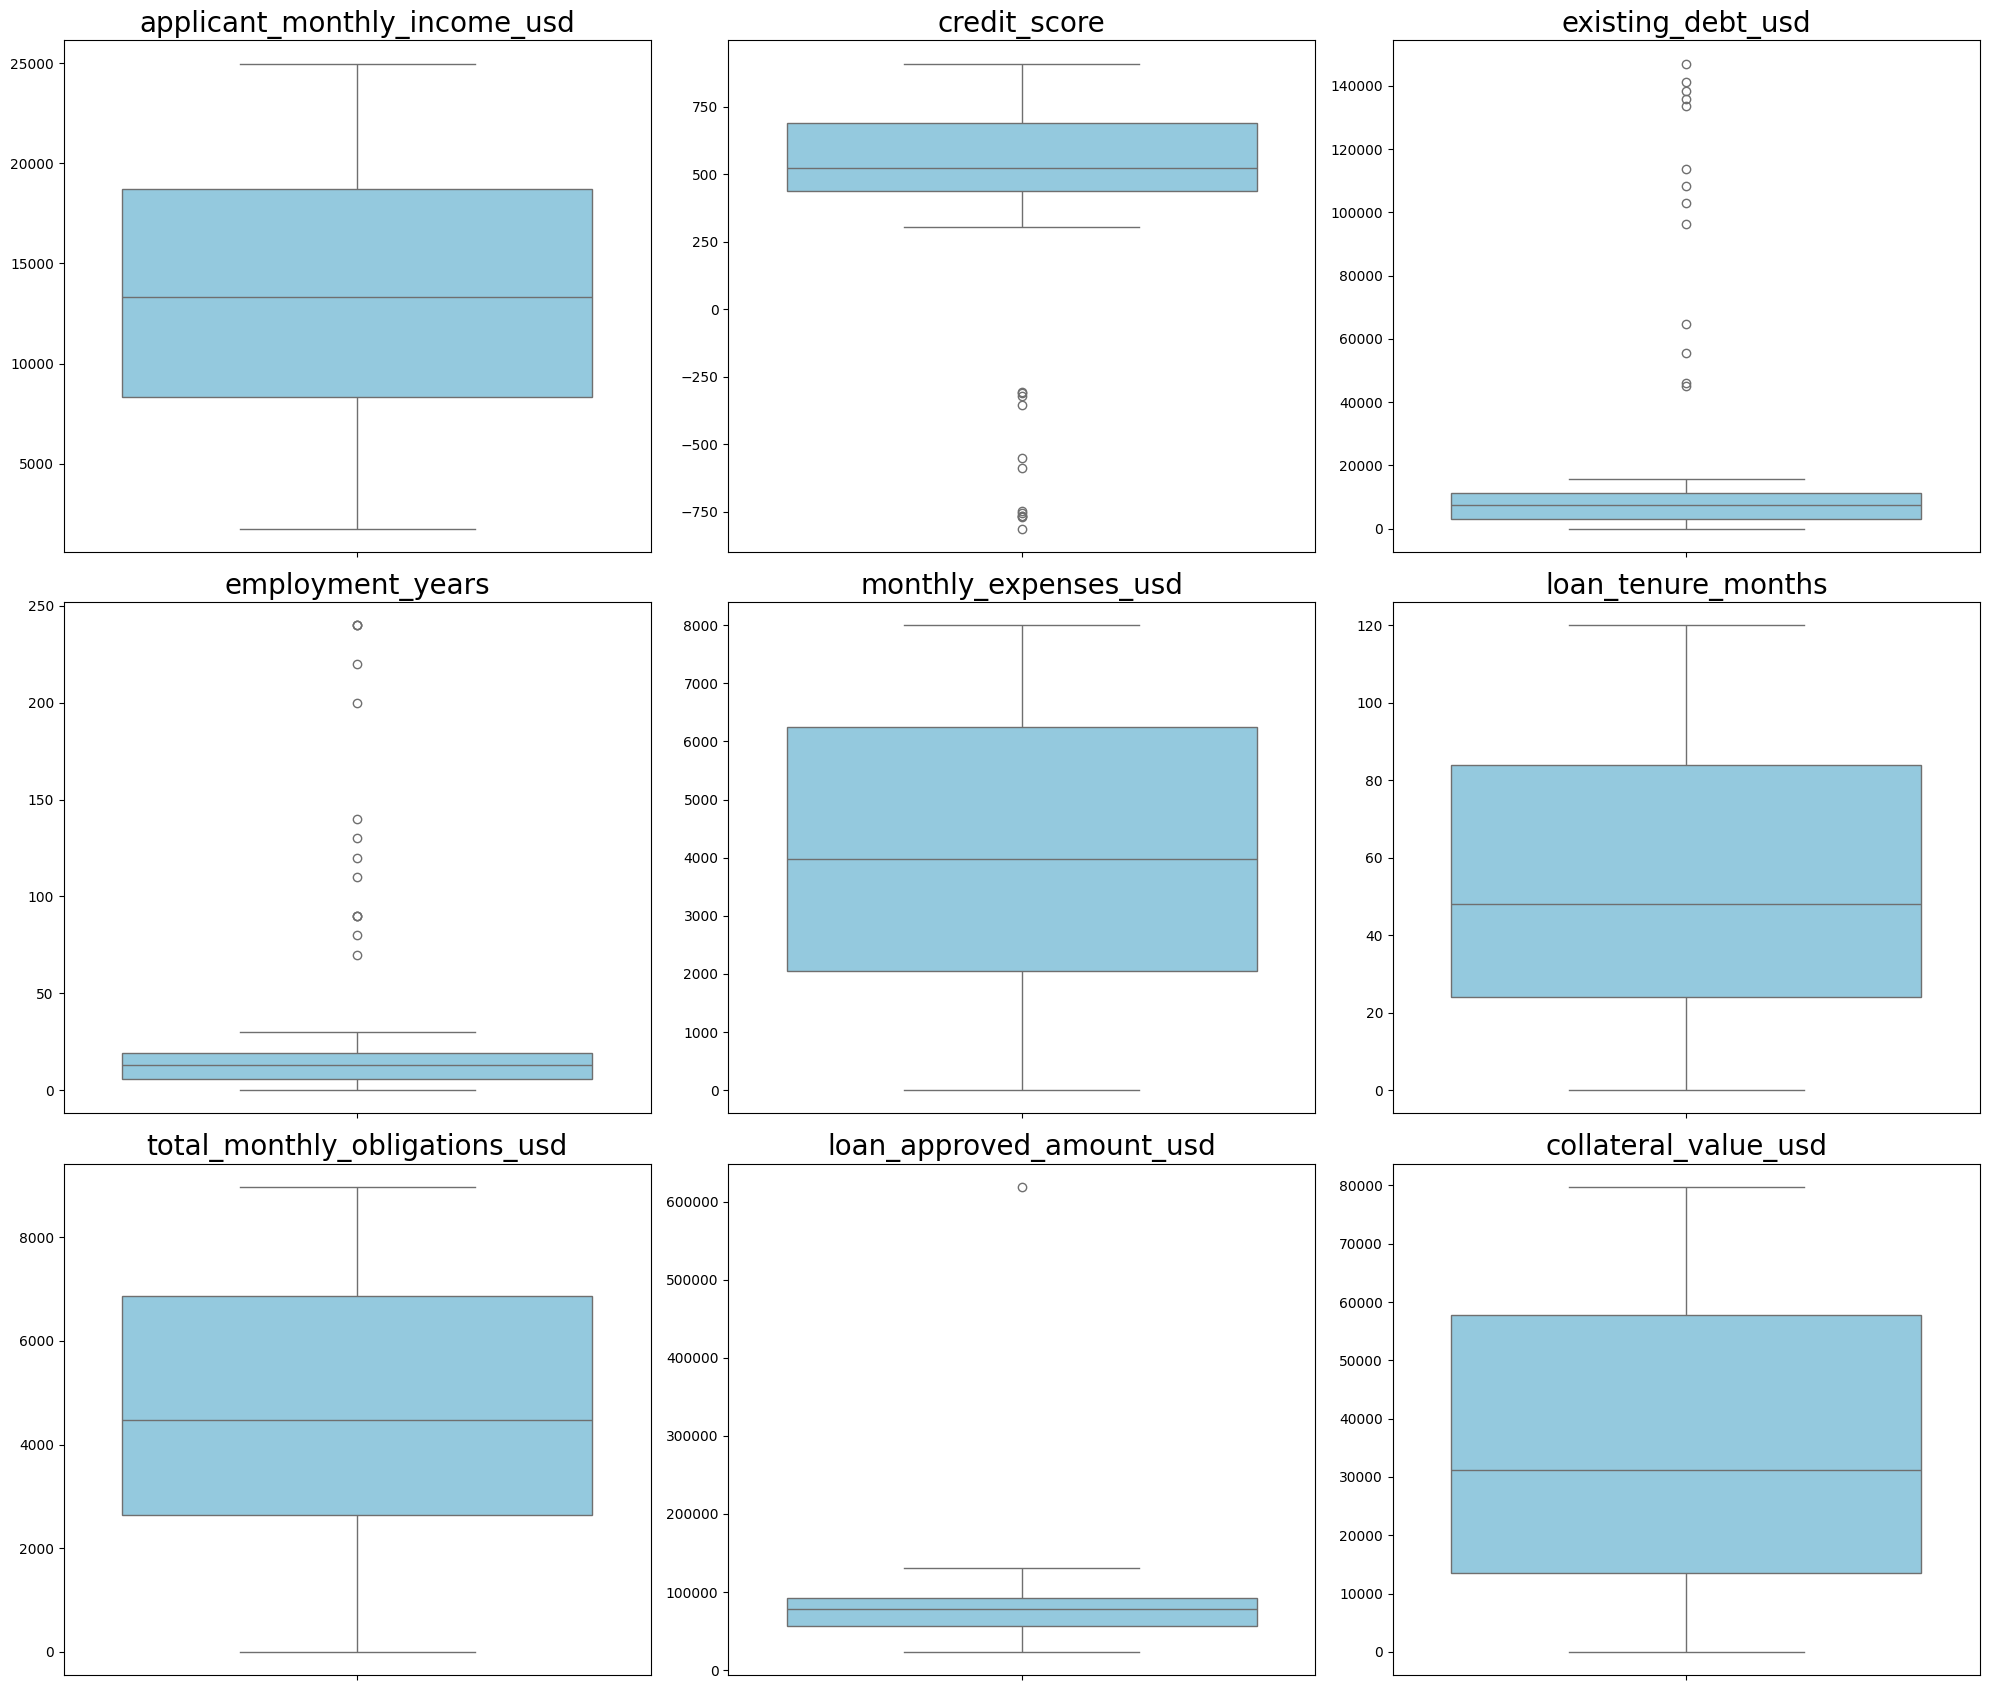

In [44]:
# define your numeric column for outliers 
cols = ["applicant_monthly_income_usd","credit_score","existing_debt_usd", "employment_years","monthly_expenses_usd", "loan_tenure_months", "total_monthly_obligations_usd" ,"loan_approved_amount_usd", "collateral_value_usd"]

# Set up grid
fig, axes = plt.subplots(3, 3, figsize=(20, 17))

#Flatten the 2D axes array into a 1D array of length 9
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=20)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

#### Observattion 
There are outliers in the following column: existing debt, employment years 
Dealing with it using the formal simple method 


In [51]:
Q1 = df["existing_debt_usd"].quantile(0.25)
Q3 = df["existing_debt_usd"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["existing_debt_usd"] >= lower) & (df["existing_debt_usd"] <= upper)]

In [49]:
Q1 = df["credit_score"].quantile(0.25)
Q3 = df["credit_score"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["credit_score"] >= lower) & (df["credit_score"] <= upper)]

In [52]:
Q1 = df["employment_years"].quantile(0.25)
Q3 = df["employment_years"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["employment_years"] >= lower) & (df["employment_years"] <= upper)]

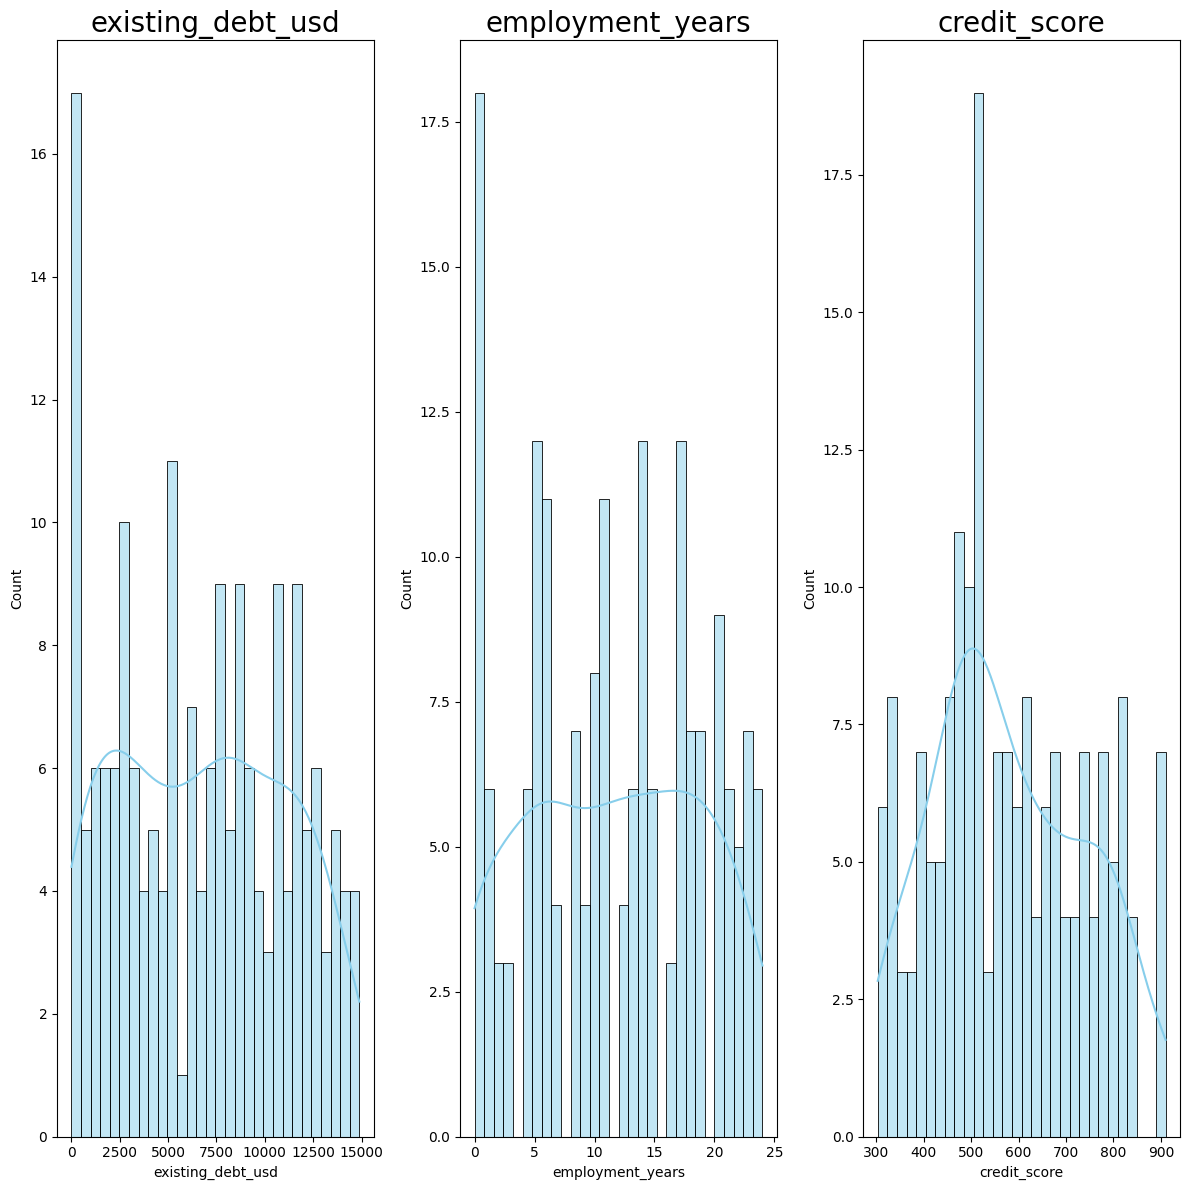

In [53]:
cols = ["existing_debt_usd", "employment_years" ,"credit_score"]

# Set up grid
fig, axes = plt.subplots(1, 3, figsize=(12, 12))



for i, col in enumerate(cols):
    sns.histplot(data = df,  x = col , bins=30,  # Number of intervals
    kde=True,  # Smooth density line
    color="skyblue",
    edgecolor="black",ax = axes[i])
    axes[i].set_title(col, fontsize=20)
plt.tight_layout()  # Added: prevents overlapping titles/labels
plt.show()

In [56]:
df

,region,employment_type,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,bank_data_version,loan_approved_amount_usd
0,Abuja,Self_employed,16825.0,484.000000,9498.0,2.0,21282.0,7295.0,84.0,8086.500000,V2_1,67244.0
2,Abuja,Self_employed,14432.0,591.000000,6142.0,10.0,32986.0,6960.0,60.0,7471.833333,V2_1,73196.0
3,Lagos,Business_owner,23593.0,508.960199,5211.0,23.0,53255.0,2438.0,60.0,2872.250000,V2_1,106918.0
4,Port_harcourt,Business_owner,24972.0,479.000000,11832.0,5.0,47170.0,1614.0,12.0,2600.000000,V2_1,110359.0
5,Abuja,Self_employed,17274.0,545.000000,4061.0,8.0,3099.0,4711.0,24.0,5049.416667,V2_1,78869.0
...,...,...,...,...,...,...,...,...,...,...,...,...
210,Kano,Business_owner,22761.0,741.000000,7099.0,14.0,69770.0,1808.0,48.0,2399.583333,V2_1,130986.0
212,Kano,Business_owner,21512.0,474.000000,1968.0,11.0,45662.0,5966.0,120.0,6130.000000,V2_1,103280.0
213,Kano,Salaried,10983.0,701.000000,6347.0,17.0,58388.0,6145.0,60.0,6673.916667,V2_1,83707.0
214,Ibadan,Salaried,8726.0,324.000000,2981.0,18.0,6848.0,5559.0,84.0,5807.416667,V2_1,37143.0


Now i am done with all the data cleaning. I am going to use dummy encoding and a variance threshold to help in variable selection 

In [57]:
# getting my encoded data using get_dummies
df_encoded = pd.get_dummies(df, drop_first = True)
df_encoded

,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,loan_approved_amount_usd,region_Ibadan,region_Kano,region_Lagos,region_Nan,region_Port_harcourt,employment_type_Nan,employment_type_Salaried,employment_type_Self_employed,bank_data_version_V2_0,bank_data_version_V2_1
0,16825.0,484.000000,9498.0,2.0,21282.0,7295.0,84.0,8086.500000,67244.0,False,False,False,False,False,False,False,True,False,True
2,14432.0,591.000000,6142.0,10.0,32986.0,6960.0,60.0,7471.833333,73196.0,False,False,False,False,False,False,False,True,False,True
3,23593.0,508.960199,5211.0,23.0,53255.0,2438.0,60.0,2872.250000,106918.0,False,False,True,False,False,False,False,False,False,True
4,24972.0,479.000000,11832.0,5.0,47170.0,1614.0,12.0,2600.000000,110359.0,False,False,False,False,True,False,False,False,False,True
5,17274.0,545.000000,4061.0,8.0,3099.0,4711.0,24.0,5049.416667,78869.0,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,22761.0,741.000000,7099.0,14.0,69770.0,1808.0,48.0,2399.583333,130986.0,False,True,False,False,False,False,False,False,False,True
212,21512.0,474.000000,1968.0,11.0,45662.0,5966.0,120.0,6130.000000,103280.0,False,True,False,False,False,False,False,False,False,True
213,10983.0,701.000000,6347.0,17.0,58388.0,6145.0,60.0,6673.916667,83707.0,False,True,False,False,False,False,True,False,False,True
214,8726.0,324.000000,2981.0,18.0,6848.0,5559.0,84.0,5807.416667,37143.0,True,False,False,False,False,False,True,False,False,True


In [58]:
# checking for the shape 
df_encoded.shape

(183, 19)

#### We now have 183 observations and 19 columns
I want to check for the correlation among predictors and the response 

In [59]:
df_encoded.corr()

,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,loan_approved_amount_usd,region_Ibadan,region_Kano,region_Lagos,region_Nan,region_Port_harcourt,employment_type_Nan,employment_type_Salaried,employment_type_Self_employed,bank_data_version_V2_0,bank_data_version_V2_1
applicant_monthly_income_usd,1.000000,0.005715,0.065396,-0.033192,-0.031740,-0.139020,-0.083681,-0.118075,0.304876,-0.135960,-0.068422,0.136168,-0.002288,-0.010689,-0.002288,0.018885,-0.136029,0.025137,0.005812
credit_score,0.005715,1.000000,0.032288,-0.104171,0.112856,0.087967,-0.083021,0.084804,0.259060,-0.165047,0.043049,0.166546,-0.032985,-0.020311,-0.032985,0.052619,-0.037705,-0.004139,-0.028315
existing_debt_usd,0.065396,0.032288,1.000000,0.252945,-0.004093,0.052238,0.068827,0.175569,0.034643,0.044844,-0.030702,0.013262,-0.113737,0.036849,-0.113737,0.030383,-0.104502,-0.257166,0.106322
employment_years,-0.033192,-0.104171,0.252945,1.000000,-0.130066,-0.141225,0.025481,-0.122244,0.016860,0.038655,0.186106,-0.070002,-0.116670,0.055802,-0.116670,0.134783,-0.135688,-0.263797,0.289719
collateral_value_usd,-0.031740,0.112856,-0.004093,-0.130066,1.000000,0.036503,0.006783,0.035268,0.214689,0.017409,0.060948,0.038629,-0.114693,0.025276,-0.114693,-0.063496,0.007094,-0.011264,0.107707
monthly_expenses_usd,-0.139020,0.087967,0.052238,-0.141225,0.036503,1.000000,-0.005344,0.988995,0.003289,0.059406,-0.016519,-0.065020,-0.129651,-0.016092,-0.129651,-0.029258,0.128400,0.053438,-0.036484
loan_tenure_months,-0.083681,-0.083021,0.068827,0.025481,0.006783,-0.005344,1.000000,-0.003191,-0.009919,0.035116,0.003276,0.037963,-0.117477,-0.149003,-0.117477,-0.037582,0.100436,-0.139513,0.093236
total_monthly_obligations_usd,-0.118075,0.084804,0.175569,-0.122244,0.035268,0.988995,-0.003191,1.000000,0.009572,0.065131,-0.023346,-0.056262,-0.146021,-0.008528,-0.146021,-0.012440,0.099578,0.069373,-0.046964
loan_approved_amount_usd,0.304876,0.259060,0.034643,0.016860,0.214689,0.003289,-0.009919,0.009572,1.000000,0.057915,-0.030304,0.034901,-0.003190,-0.039960,-0.003190,-0.055637,-0.095325,-0.011804,0.047287
region_Ibadan,-0.135960,-0.165047,0.044844,0.038655,0.017409,0.059406,0.035116,0.065131,0.057915,1.000000,-0.278994,-0.231745,-0.037315,-0.231745,-0.037315,0.060287,-0.067345,-0.084372,0.001308


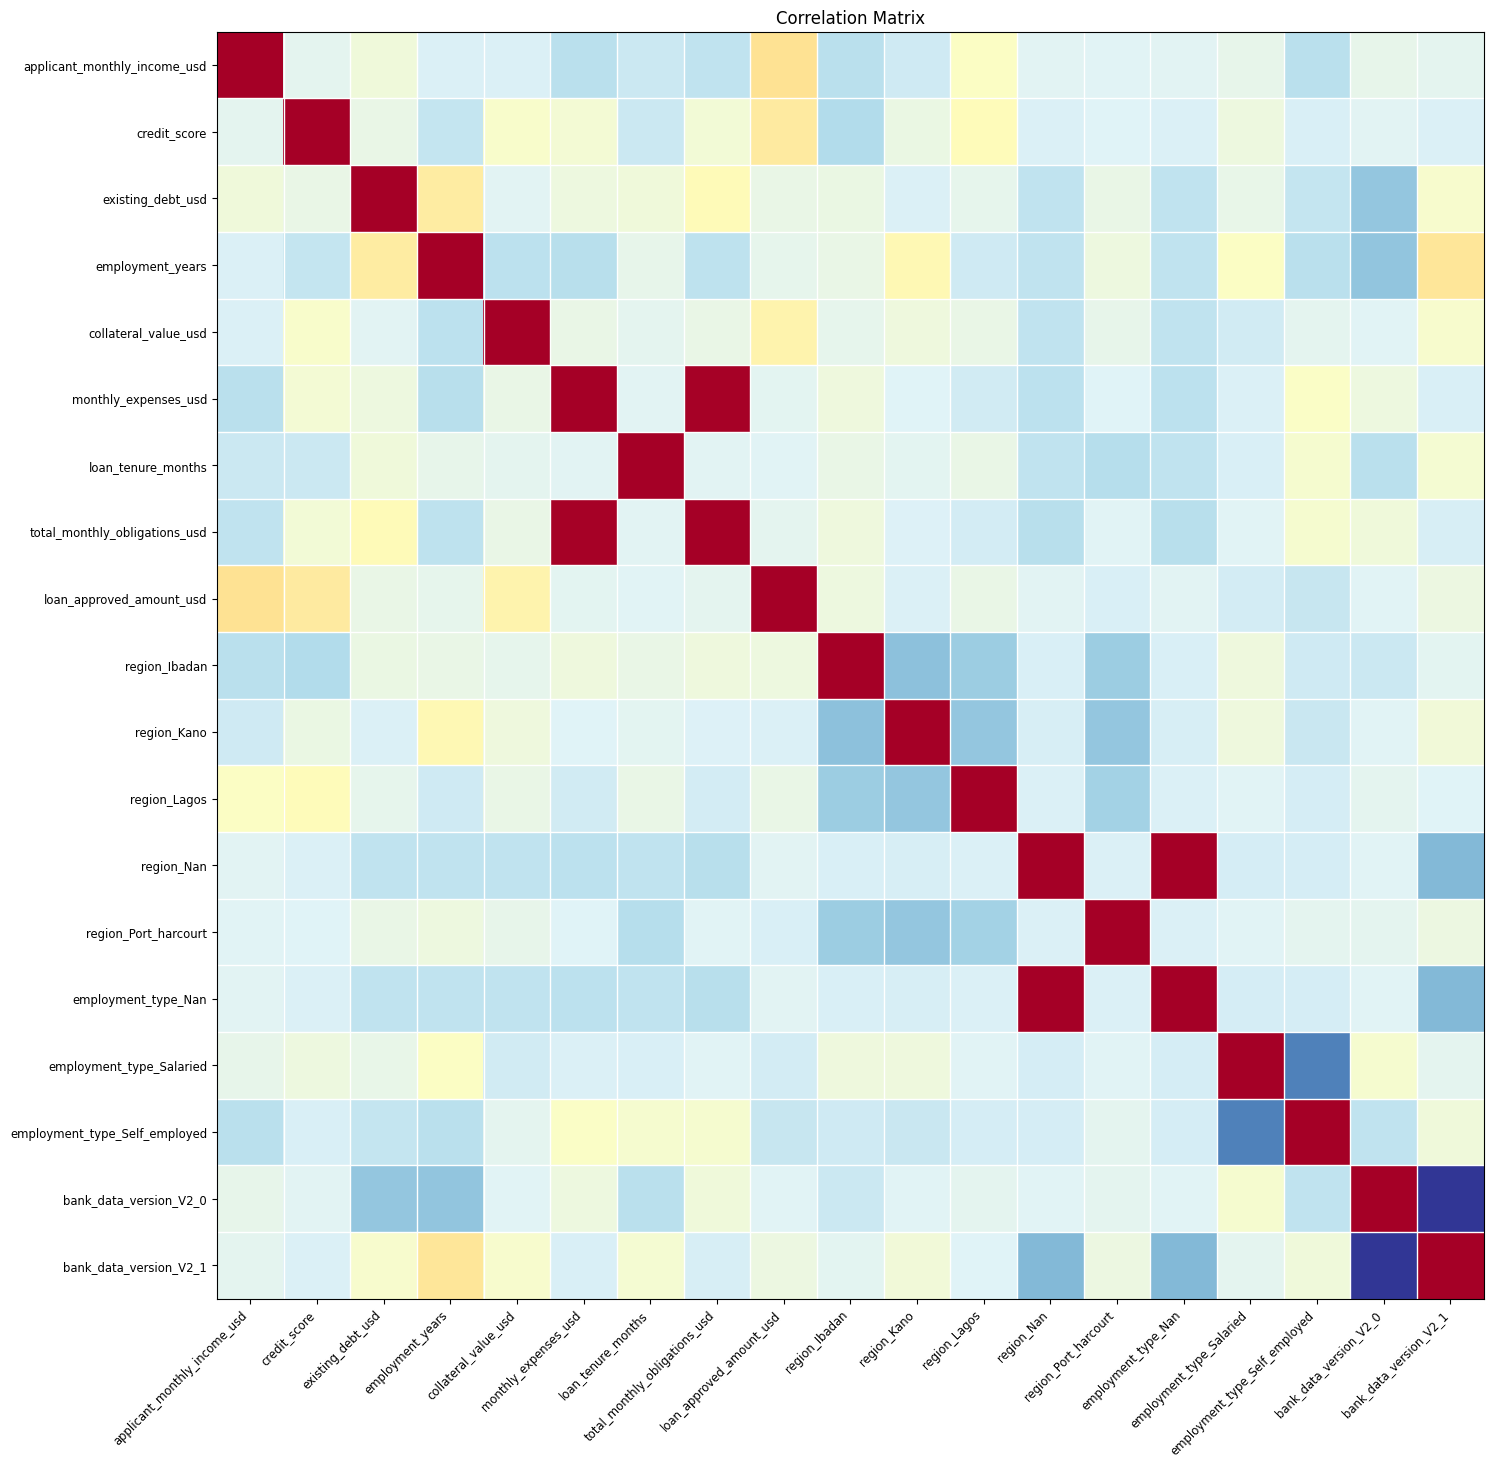

In [60]:
from statsmodels.graphics.correlation import plot_corr
fig = plt.figure(figsize =(15,15));
ax = fig.add_subplot(111);
plot_corr(df_encoded.corr(), xnames = df_encoded.corr().columns, ax = ax);

We can see from the correlations that it's not the best idea to keep all of the dummy variables.

If we use all of these variables, we're effectively working with **superfluous or redundant information**. 

Our model will also have **collinearity issues**:
Let us check the model by using statsmodels

In [61]:
#fitting the model using statsmodels.ols
#create a data model for the model 
dfm = df_encoded.copy()
Y_data = "loan_approved_amount_usd"
X_data = [col for col in dfm.columns if col != "loan_approved_amount_usd"]
formula_str = Y_data + "~" + "+".join(X_data)
print("formula: \n\t{}".format(formula_str))

formula: 
	loan_approved_amount_usd~applicant_monthly_income_usd+credit_score+existing_debt_usd+employment_years+collateral_value_usd+monthly_expenses_usd+loan_tenure_months+total_monthly_obligations_usd+region_Ibadan+region_Kano+region_Lagos+region_Nan+region_Port_harcourt+employment_type_Nan+employment_type_Salaried+employment_type_Self_employed+bank_data_version_V2_0+bank_data_version_V2_1


In [62]:
from statsmodels.formula.api import ols
model = ols(formula = formula_str, data = dfm)
fitted = model.fit()
print(fitted.summary())

                               OLS Regression Results                               
Dep. Variable:     loan_approved_amount_usd   R-squared:                       0.245
Model:                                  OLS   Adj. R-squared:                  0.168
Method:                       Least Squares   F-statistic:                     3.157
Date:                      Wed, 02 Sep 2026   Prob (F-statistic):           7.16e-05
Time:                              02:55:50   Log-Likelihood:                -2198.1
No. Observations:                       183   AIC:                             4432.
Df Residuals:                           165   BIC:                             4490.
Df Model:                                17                                         
Covariance Type:                  nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

$R^2$ = 0.228 (Adjusted $R^2$ = 0.162): Your model explains about 22.8% of the variance in loan_approved_amount_usd. The remaining ~77% is unexplained by these features.Prob (F-statistic) = $3.81 \times 10^{-5}$ ($0.0000381$): This value is well below $0.05$, meaning the model as a whole is statistically significant—at least one variable reliably predicts the loan amount.

Out of 15 features, only 3 variables have a statistically significant impact on the approved loan amount:
applicant_monthly_income_usd, credit_score, collateral_value_usd

In [63]:
#Variance Threshold 
#The dependent and independent variables 
X_var = df_encoded.drop(columns = ["loan_approved_amount_usd"])
Y_var = df_encoded["loan_approved_amount_usd"]
Scaler = MinMaxScaler()

In [64]:
#Normalize and scale 
X_scaled = Scaler.fit_transform(X_var)
X_normalize = pd.DataFrame(X_scaled, columns = X_var.columns)
X_normalize

,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,region_Ibadan,region_Kano,region_Lagos,region_Nan,region_Port_harcourt,employment_type_Nan,employment_type_Salaried,employment_type_Self_employed,bank_data_version_V2_0,bank_data_version_V2_1
0,0.648882,0.298188,0.638135,0.083333,0.266846,0.912103,0.7,0.901187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.545748,0.474465,0.412658,0.416667,0.413597,0.870218,0.5,0.832686,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.940568,0.339308,0.350107,0.958333,0.667741,0.304826,0.5,0.320093,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.000000,0.289951,0.794948,0.208333,0.591444,0.201800,0.1,0.289753,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.668233,0.398682,0.272843,0.333333,0.038857,0.589022,0.2,0.562724,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.904711,0.721582,0.476955,0.583333,0.874815,0.226057,0.4,0.267418,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
179,0.850881,0.281713,0.132223,0.458333,0.572536,0.745936,1.0,0.683148,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
180,0.397104,0.655684,0.426431,0.708333,0.732101,0.768317,0.5,0.743764,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
181,0.299832,0.034596,0.200282,0.750000,0.085864,0.695049,0.7,0.647198,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [65]:
#Applying the variance threshold 0.03 
selector = VarianceThreshold(threshold = 0.03)
filtered_variance = selector.fit_transform(X_normalize)


In [66]:
#putting it in dataframe
df_filtered_variance = pd.DataFrame(filtered_variance, columns = X_normalize.columns[selector.get_support(indices = True)])
df_filtered_variance

,applicant_monthly_income_usd,credit_score,existing_debt_usd,employment_years,collateral_value_usd,monthly_expenses_usd,loan_tenure_months,total_monthly_obligations_usd,region_Ibadan,region_Kano,region_Lagos,region_Port_harcourt,employment_type_Salaried,employment_type_Self_employed,bank_data_version_V2_1
0,0.648882,0.298188,0.638135,0.083333,0.266846,0.912103,0.7,0.901187,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.545748,0.474465,0.412658,0.416667,0.413597,0.870218,0.5,0.832686,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,0.940568,0.339308,0.350107,0.958333,0.667741,0.304826,0.5,0.320093,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.000000,0.289951,0.794948,0.208333,0.591444,0.201800,0.1,0.289753,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.668233,0.398682,0.272843,0.333333,0.038857,0.589022,0.2,0.562724,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.904711,0.721582,0.476955,0.583333,0.874815,0.226057,0.4,0.267418,0.0,1.0,0.0,0.0,0.0,0.0,1.0
179,0.850881,0.281713,0.132223,0.458333,0.572536,0.745936,1.0,0.683148,0.0,1.0,0.0,0.0,0.0,0.0,1.0
180,0.397104,0.655684,0.426431,0.708333,0.732101,0.768317,0.5,0.743764,0.0,1.0,0.0,0.0,1.0,0.0,1.0
181,0.299832,0.034596,0.200282,0.750000,0.085864,0.695049,0.7,0.647198,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [67]:
column_variances = selector.variances_

vars_dict = {}
vars_dict = [{"Variable_Name": c_name, "Variance": c_var}
             for c_name, c_var in zip(X_normalize.columns, column_variances)]
df_vars = pd.DataFrame(vars_dict)
df_vars.sort_values(by='Variance', ascending=False)

,Variable_Name,Variance
15,employment_type_Self_employed,0.222222
14,employment_type_Salaried,0.218460
9,region_Kano,0.179761
8,region_Ibadan,0.161307
12,region_Port_harcourt,0.144286
10,region_Lagos,0.144286
3,employment_years,0.092988
4,collateral_value_usd,0.090416
2,existing_debt_usd,0.086634
6,loan_tenure_months,0.085490


In [68]:
X_new = X_normalize[X_normalize.columns[selector.get_support(indices=True)]]

In [69]:
formula_str = Y_data + "~" + "+".join(X_new)
print("formula: \n\t{}".format(formula_str))

formula: 
	loan_approved_amount_usd~applicant_monthly_income_usd+credit_score+existing_debt_usd+employment_years+collateral_value_usd+monthly_expenses_usd+loan_tenure_months+total_monthly_obligations_usd+region_Ibadan+region_Kano+region_Lagos+region_Port_harcourt+employment_type_Salaried+employment_type_Self_employed+bank_data_version_V2_1


In [70]:
from statsmodels.formula.api import ols
model = ols(formula = formula_str, data = df_encoded)
fitted = model.fit()
print(fitted.summary())

                               OLS Regression Results                               
Dep. Variable:     loan_approved_amount_usd   R-squared:                       0.242
Model:                                  OLS   Adj. R-squared:                  0.173
Method:                       Least Squares   F-statistic:                     3.547
Date:                      Wed, 02 Sep 2026   Prob (F-statistic):           2.62e-05
Time:                              03:00:15   Log-Likelihood:                -2198.6
No. Observations:                       183   AIC:                             4429.
Df Residuals:                           167   BIC:                             4481.
Df Model:                                15                                         
Covariance Type:                  nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [71]:
#Training and testing using my filtered dataset
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(df_filtered_variance, Y_var, test_size = 0.20, random_state = 50)



In [72]:
#model fitting LinearRegression()
model_filtered = LinearRegression()
model_filtered.fit(X_train_filtered, y_train_filtered)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
Prediction = model_filtered.predict(X_train_filtered)

In [74]:
MSE = metrics.mean_squared_error(y_train_filtered, Prediction)
R_squared = metrics.r2_score(y_train_filtered, Prediction)
print(MSE)
print(R_squared)

43457359.24987967
0.9187200222586316


In [75]:
# the test part 
test_prediction = model_filtered.predict(X_test_filtered)

In [76]:
MSE = metrics.mean_squared_error(y_test_filtered, test_prediction)
R_squared = metrics.r2_score(y_test_filtered, test_prediction)
print(MSE)
print(R_squared)

8501703562.64974
-0.05832902491592096


This is a clear, textbook overfitting signature — and a fairly severe one.

What the numbers say:

Train R² = 0.92 → the model explains 92% of variance on the data it was trained on.

Test R² = -0.058 → negative. That means on unseen data, the model does worse than simply predicting the average loan amount every time, for every applicant.

Test MSE is ~200x larger than train MSE (8.5B vs 43M).

It means the model has essentially memorized the training rows rather than learning a transferable relationship. It has zero real predictive power on new applicants right now.
Too many features relative to rows. 

190 rows after cleaning, and once you one-hot encode region, employment_type, bank_data_version, you can easily end up with 15+ predictor columns. A linear model with that many parameters relative to so few observations has enormous freedom to fit noise; this is the single most likely cause here.
The variance threshold filter doesn't protect against this. It only removes near-constant columns; it does nothing to control how many parameters your model is estimating relative to your sample size.
